## 1. Import Libraries and Setup

In [2]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Import KMRF and strategy classes
from kmrf import KMRF
from KMRF_training_config import KMRF_Training_Config
from regime_trading_strategy_rules import *

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ Libraries imported successfully")
print(f"Notebook initialized: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

✓ Libraries imported successfully
Notebook initialized: 2025-11-19 22:19:44


## 2. Load Model and Generate Predictions

In [3]:
test_or_val_set = 'test'
model = KMRF.load_model('saved_models/KMRF_new/original/us_equity/SPDR S&P 500 ETF_KMRF_model.pkl')

KMRF model initialized
  Asset: SPDR S&P 500 ETF
  Asset class: us_equity
  Classification type: original
  Training end date: 20181231
  Test end date: All available data
  Data type: master
  Data path: /Users/jessegoodman/Desktop/Stevens MFE/Sem3/FE800/FE800_project_code/data/master_df.csv
  KAMA+MSR model directory: /Users/jessegoodman/Desktop/Stevens MFE/Sem3/FE800/FE800_project_code/saved_models/KAMA_MSR/us_equity/20181231
  Validation/Test split: Will be calculated after loading data
  Random seed: 1010
  Feature window size: 1 days
  Feature asset classes: []
  Feature selection: Boruta=True, Consensus=False
  Custom XGB parameters: {'n_estimators': 220, 'max_depth': 13, 'learning_rate': 0.1, 'subsample': 0.8, 'colsample_bytree': 0.25, 'min_child_weight': 95, 'gamma': 0.045, 'random_state': 1010, 'n_jobs': -1, 'tree_method': 'hist', 'enable_categorical': False}


In [4]:
# Generate predictions on validation set
print("\nGenerating validation predictions...")
predictions = model.predict(test_or_val=test_or_val_set)
# Visualize predictions
print("\n" + "="*80)
print("VISUALIZING PREDICTIONS")
print("="*80)
model.viz_predictions(test_or_val=test_or_val_set)


Generating validation predictions...

Generating predictions...
  Input shape: (957, 109)
  Using pre-selected features: 109
✓ Generated probability predictions: (957, 4)
  Using test set: 2022-01-03 00:00:00 to 2025-10-24 00:00:00

VISUALIZING PREDICTIONS


ValueError: No test predictions available. Generate predictions first.

# Test Rules-Based Trading Strategy

In [5]:
# Load price data
print("Loading price data...")
price_data = model.raw_ohlc.droplevel(0, axis=1)

# Extract Open and Close prices
prices = pd.DataFrame({
    'Open': price_data['open'],
    'Close': price_data['close']
}, index=price_data.index)

# Align predictions with price data
aligned_predictions = predictions.reindex(prices.index).dropna()
aligned_prices = prices.reindex(aligned_predictions.index)

print(f"✓ Price data loaded: {len(prices)} days")
print(f"  Date range: {prices.index[0].date()} to {prices.index[-1].date()}")

Loading price data...
✓ Price data loaded: 8247 days
  Date range: 1993-01-29 to 2025-10-31


## 3. Initialize Rules-Based Strategy

The rules-based strategy uses a state machine with explicit rules for each regime transition:
- **LV Bull** → LONG
- **HV Bull** → UNINVESTED (close any position)
- **LV Bear** → SHORT (with recovery logic)
- **HV Bear** → SHORT (hold until exit)

Recovery logic allows going LONG after exiting bear regimes, with patience parameters controlling timeouts.

In [6]:
# Create strategy parameters
# These control how long to hold recovery longs before giving up
params = StrategyParameters(
    lv_bear_patience=63,  # Days to hold long after LV Bear short cover
    hv_bear_patience=63,  # Days to hold long after HV Bear exit to LV Bear
    position_size=1.0,   # Full investment (100%)
    transaction_cost=0.0004  # 4 basis points
)

print("Strategy Parameters:")
print(params)
print("\n" + "="*80)

Strategy Parameters:
StrategyParameters:
  lv_bear_patience: 63 periods
  hv_bear_patience: 63 periods
  position_size: 1.0
  transaction_cost: 0.0004



In [7]:
# Initialize strategy
print("Initializing Rules-Based Regime Strategy...")
strategy = RulesBasedRegimeStrategy(aligned_predictions, aligned_prices, params)
print("✓ Strategy initialized successfully")

Initializing Rules-Based Regime Strategy...
✓ Strategy initialized successfully


## 4. Generate Trading Signals

Generate signals using the state machine rules. The strategy will determine positions based on regime transitions.

In [8]:
# Generate signals
print("Generating trading signals...")
signals = strategy.generate_signals()

print("✓ Signals generated successfully")
print(f"\nSignal DataFrame shape: {signals.shape}")
print(f"\nColumns: {list(signals.columns)}")
print(f"\nFirst few signals:")
print(signals.head(10))

Generating trading signals...
✓ Signals generated successfully

Signal DataFrame shape: (957, 7)

Columns: ['regime', 'position', 'signal_type', 'days_in_position', 'recovery_counter', 'prev_regime', 'position_size']

First few signals:
            regime  position        signal_type  days_in_position  \
date                                                                
2022-01-03       0       1.0       LV_BULL_LONG                 0   
2022-01-04       0       1.0  LV_BULL_HOLD_LONG                 1   
2022-01-05       0       1.0  LV_BULL_HOLD_LONG                 2   
2022-01-06       0       1.0  LV_BULL_HOLD_LONG                 3   
2022-01-07       0       1.0  LV_BULL_HOLD_LONG                 4   
2022-01-10       0       1.0  LV_BULL_HOLD_LONG                 5   
2022-01-11       0       1.0  LV_BULL_HOLD_LONG                 6   
2022-01-12       0       1.0  LV_BULL_HOLD_LONG                 7   
2022-01-13       0       1.0  LV_BULL_HOLD_LONG                 8   
2022

In [9]:
# Analyze signal distribution
print("="*80)
print("SIGNAL DISTRIBUTION")
print("="*80)

# Position distribution
position_counts = signals['position'].value_counts().sort_index()
print("\nPosition Distribution:")
for pos, count in position_counts.items():
    pos_name = {-1: 'SHORT', 0: 'UNINVESTED', 1: 'LONG'}[pos]
    pct = count / len(signals) * 100
    print(f"  {pos_name:>12}: {count:>5} days ({pct:>5.1f}%)")

# Regime distribution
regime_names = {0: 'LV_Bull', 1: 'LV_Bear', 2: 'HV_Bull', 3: 'HV_Bear'}
regime_counts = signals['regime'].value_counts().sort_index()
print("\nRegime Distribution:")
for regime, count in regime_counts.items():
    pct = count / len(signals) * 100
    print(f"  {regime_names[regime]:>12}: {count:>5} days ({pct:>5.1f}%)")

# Top signal types
print("\nTop 10 Signal Types:")
signal_type_counts = signals['signal_type'].value_counts().head(10)
for signal_type, count in signal_type_counts.items():
    print(f"  {signal_type:>40}: {count:>4} times")

SIGNAL DISTRIBUTION

Position Distribution:
         SHORT:    78 days (  8.2%)
    UNINVESTED:     5 days (  0.5%)
          LONG:   874 days ( 91.3%)

Regime Distribution:
       LV_Bull:   700 days ( 73.1%)
       LV_Bear:   233 days ( 24.3%)
       HV_Bear:    24 days (  2.5%)

Top 10 Signal Types:
                         LV_BULL_HOLD_LONG:  692 times
                                HOLD_SHORT:   59 times
                             LV_BEAR_SHORT:   10 times
                             HV_BEAR_SHORT:    9 times
        LV_BEAR_FROM_HV_BEAR_RECOVERY_LONG:    9 times
                              LV_BULL_LONG:    8 times
              LV_BEAR_RECOVERY_LONG_WAIT_1:    7 times
              LV_BEAR_RECOVERY_LONG_WAIT_2:    7 times
              LV_BEAR_RECOVERY_LONG_WAIT_6:    5 times
              LV_BEAR_RECOVERY_LONG_WAIT_8:    5 times


## 5. Backtest Strategy

Run the backtest to evaluate strategy performance against buy-and-hold.

In [10]:
# Run backtest
print("Running backtest...")
results = strategy.backtest()

# Display performance summary
print("\n" + strategy.get_summary())

Running backtest...


╔══════════════════════════════════════════════════════════════╗
║         RULES-BASED REGIME STRATEGY SUMMARY                  ║
╚══════════════════════════════════════════════════════════════╝

STRATEGY PERFORMANCE:
  Total Return:          6.64%
  Annualized Return:     1.71%
  Volatility:           18.27%
  Sharpe Ratio:          0.093
  Max Drawdown:        -28.69%
  
BUY & HOLD PERFORMANCE:
  Total Return:         41.77%
  Annualized Return:     9.63%
  Volatility:           18.29%
  Sharpe Ratio:          0.526
  Max Drawdown:        -25.34%

EXCESS PERFORMANCE:
  Excess Return:       -35.13%
  
TRADING STATISTICS:
  Number of Trades:         41
  Win Rate:             52.36%

POSITION ALLOCATION:
  Long Days:            91.33%
  Short Days:            8.15%
  Uninvested Days:       0.52%
  
PARAMETERS:
  LV Bear Patience:         63 periods
  HV Bear Patience:         63 periods
  Position Size:           1.0

══════════════════════════════════════════════

## 6. Visualize Performance

Plot the strategy performance including:
- Cumulative returns vs buy-and-hold
- Positions over time (Long/Short/Uninvested)
- Regime predictions
- Position allocation

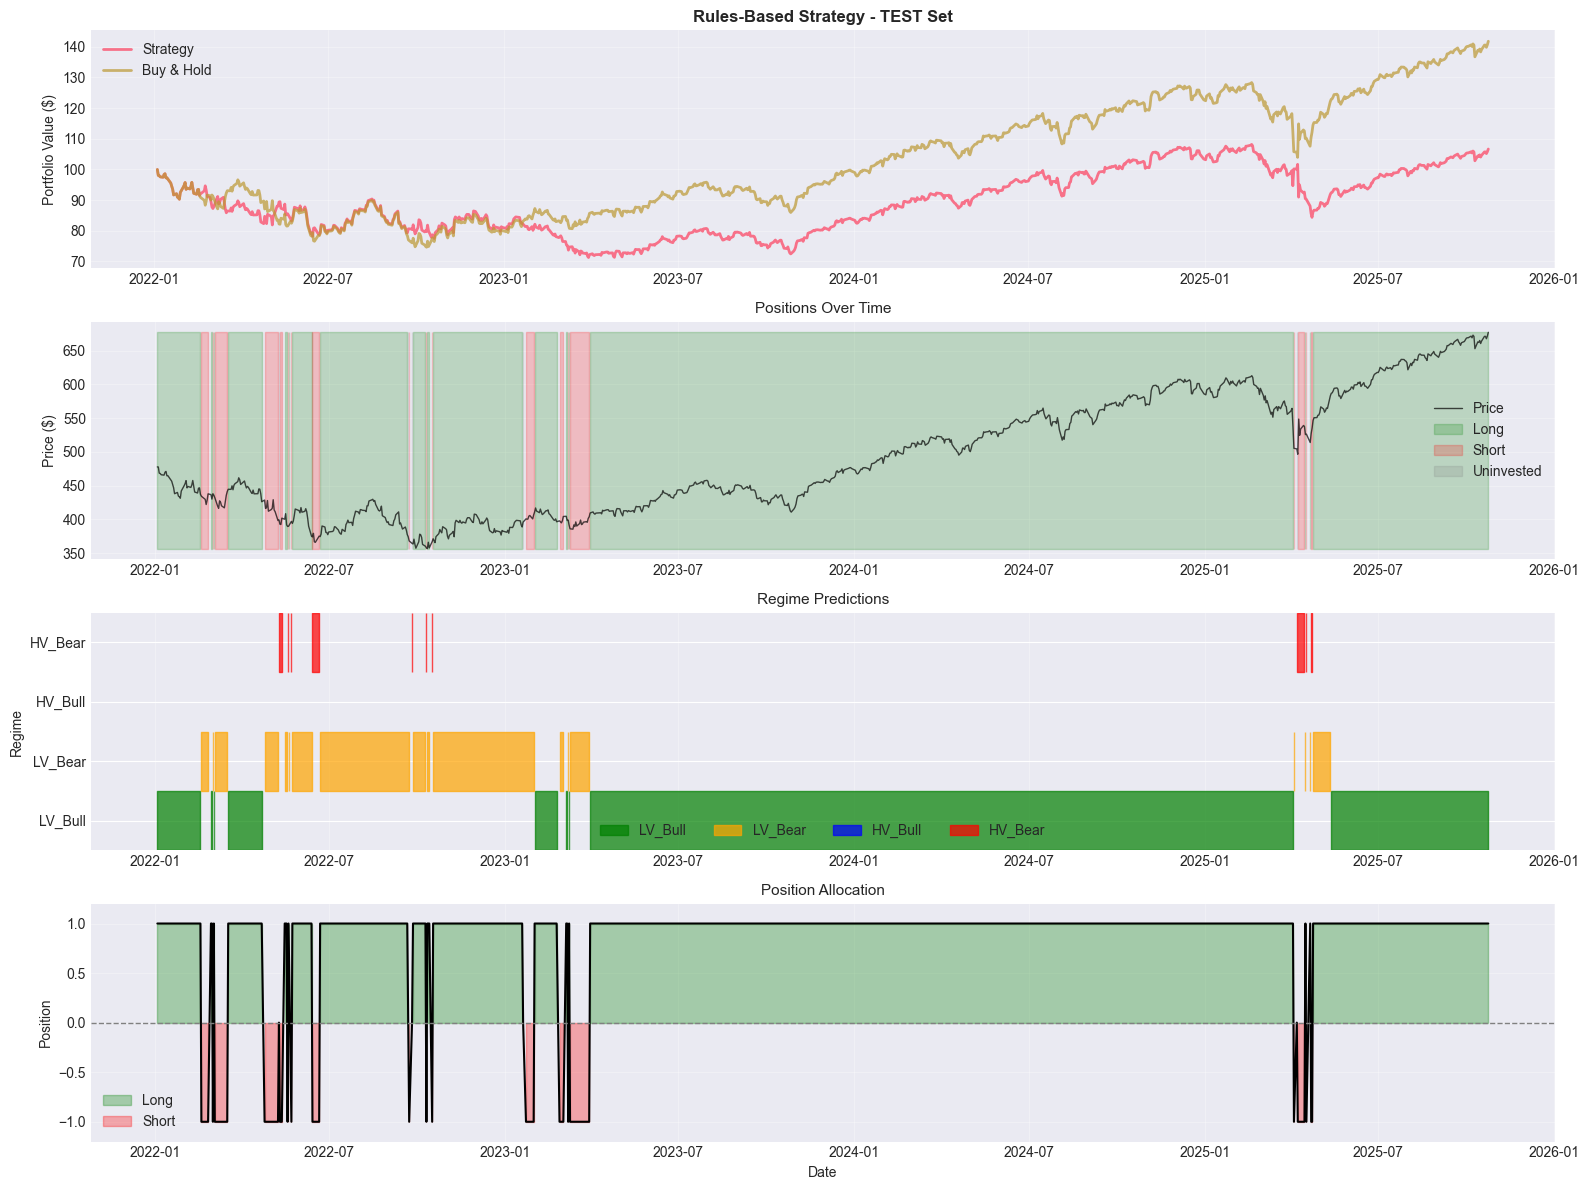

In [11]:
# Plot performance
fig = strategy.plot_performance(title=f'Rules-Based Strategy - {test_or_val_set.upper()} Set')
plt.show()

## 7. Detailed Signal Analysis

Examine specific regime transitions and signal types to understand strategy behavior.

In [ ]:
# Find regime transitions
print("="*80)
print("REGIME TRANSITIONS")
print("="*80)

signals['regime_changed'] = signals['regime'] != signals['prev_regime']
transitions = signals[signals['regime_changed']].copy()

regime_names = {0: 'LV_Bull', 1: 'LV_Bear', 2: 'HV_Bull', 3: 'HV_Bear'}
transitions['regime_name'] = transitions['regime'].map(regime_names)
transitions['prev_regime_name'] = transitions['prev_regime'].map(regime_names)

print(f"\nTotal regime transitions: {len(transitions)}")
print("\nFirst 10 transitions:")
print(transitions[['prev_regime_name', 'regime_name', 'position', 'signal_type']].head(10))

REGIME TRANSITIONS

Total regime transitions: 46

First 10 transitions:
           prev_regime_name regime_name  position    signal_type
date                                                            
2022-02-14          LV_Bull     LV_Bear      -1.0  LV_BEAR_SHORT
2022-02-16          LV_Bear     LV_Bull       1.0   LV_BULL_LONG
2022-02-18          LV_Bull     LV_Bear      -1.0  LV_BEAR_SHORT
2022-03-21          LV_Bear     LV_Bull       1.0   LV_BULL_LONG
2022-03-22          LV_Bull     LV_Bear      -1.0  LV_BEAR_SHORT
2022-03-23          LV_Bear     LV_Bull       1.0   LV_BULL_LONG
2022-03-24          LV_Bull     LV_Bear      -1.0  LV_BEAR_SHORT
2022-03-25          LV_Bear     LV_Bull       1.0   LV_BULL_LONG
2022-04-13          LV_Bull     LV_Bear      -1.0  LV_BEAR_SHORT
2022-04-14          LV_Bear     LV_Bull       1.0   LV_BULL_LONG


In [ ]:
# Analyze recovery trades
print("\n" + "="*80)
print("RECOVERY TRADES ANALYSIS")
print("="*80)

recovery_signals = signals[signals['signal_type'].str.contains('RECOVERY', na=False)]
print(f"\nTotal recovery trade days: {len(recovery_signals)}")

if len(recovery_signals) > 0:
    print("\nRecovery signal types:")
    for signal_type, count in recovery_signals['signal_type'].value_counts().items():
        print(f"  {signal_type:>50}: {count:>4} days")
    
    print("\nSample recovery trades:")
    print(recovery_signals[['regime', 'position', 'signal_type', 'recovery_counter']].head(10))
else:
    print("No recovery trades found in this period.")


RECOVERY TRADES ANALYSIS

Total recovery trade days: 160

Recovery signal types:
                  LV_BEAR_FROM_HV_BEAR_RECOVERY_LONG:    9 days
                        LV_BEAR_RECOVERY_LONG_WAIT_1:    6 days
                        LV_BEAR_RECOVERY_LONG_WAIT_2:    6 days
                        LV_BEAR_RECOVERY_LONG_WAIT_3:    5 days
                        LV_BEAR_RECOVERY_LONG_WAIT_4:    5 days
                        LV_BEAR_RECOVERY_LONG_WAIT_5:    5 days
                        LV_BEAR_RECOVERY_LONG_WAIT_6:    5 days
                        LV_BEAR_RECOVERY_LONG_WAIT_7:    5 days
                        LV_BEAR_RECOVERY_LONG_WAIT_8:    5 days
                        LV_BEAR_RECOVERY_LONG_WAIT_9:    5 days
                       LV_BEAR_RECOVERY_LONG_WAIT_11:    3 days
                       LV_BEAR_RECOVERY_LONG_WAIT_10:    3 days
                       LV_BEAR_RECOVERY_LONG_WAIT_46:    2 days
                       LV_BEAR_RECOVERY_LONG_WAIT_37:    2 days
                      

## 8. Parameter Sensitivity Analysis

Test different patience parameters to see how they affect performance.

In [ ]:
# Test different patience parameters
patience_values = [3, 5, 7, 10]
results_sensitivity = []

print("Testing different patience parameters...")
print("="*80)

for patience in patience_values:
    # Create parameters
    test_params = StrategyParameters(
        lv_bear_patience=patience,
        hv_bear_patience=patience,
        position_size=1.0,
        transaction_cost=0.0004
    )
    
    # Run strategy
    test_strategy = RulesBasedRegimeStrategy(predictions, prices, test_params)
    test_strategy.generate_signals()
    test_results = test_strategy.backtest()
    
    # Store results
    results_sensitivity.append({
        'patience': patience,
        'total_return': test_results['total_return'],
        'sharpe_ratio': test_results['sharpe_ratio'],
        'max_drawdown': test_results['max_drawdown'],
        'num_trades': test_results['num_trades'],
        'long_pct': test_results['long_pct'],
        'short_pct': test_results['short_pct'],
        'uninvested_pct': test_results['uninvested_pct']
    })
    
    print(f"Patience={patience:>2}: Return={test_results['total_return']:>7.2%}, "
          f"Sharpe={test_results['sharpe_ratio']:>6.3f}, "
          f"Trades={test_results['num_trades']:>4.0f}")

# Create DataFrame
sensitivity_df = pd.DataFrame(results_sensitivity)
print("\n✓ Sensitivity analysis complete")

Testing different patience parameters...


ValueError: Predictions and prices must have the same index

In [ ]:
# Plot sensitivity results
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Total Return
ax = axes[0, 0]
ax.plot(sensitivity_df['patience'], sensitivity_df['total_return'] * 100, 
        marker='o', linewidth=2, markersize=8)
ax.set_xlabel('Patience (days)', fontsize=11)
ax.set_ylabel('Total Return (%)', fontsize=11)
ax.set_title('Total Return vs Patience', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

# Sharpe Ratio
ax = axes[0, 1]
ax.plot(sensitivity_df['patience'], sensitivity_df['sharpe_ratio'], 
        marker='o', linewidth=2, markersize=8, color='green')
ax.set_xlabel('Patience (days)', fontsize=11)
ax.set_ylabel('Sharpe Ratio', fontsize=11)
ax.set_title('Sharpe Ratio vs Patience', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

# Number of Trades
ax = axes[1, 0]
ax.plot(sensitivity_df['patience'], sensitivity_df['num_trades'], 
        marker='o', linewidth=2, markersize=8, color='red')
ax.set_xlabel('Patience (days)', fontsize=11)
ax.set_ylabel('Number of Trades', fontsize=11)
ax.set_title('Trading Frequency vs Patience', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

# Position Allocation
ax = axes[1, 1]
x = sensitivity_df['patience']
ax.plot(x, sensitivity_df['long_pct'] * 100, marker='o', label='Long', linewidth=2)
ax.plot(x, sensitivity_df['short_pct'] * 100, marker='o', label='Short', linewidth=2)
ax.plot(x, sensitivity_df['uninvested_pct'] * 100, marker='o', label='Uninvested', linewidth=2)
ax.set_xlabel('Patience (days)', fontsize=11)
ax.set_ylabel('Allocation (%)', fontsize=11)
ax.set_title('Position Allocation vs Patience', fontsize=12, fontweight='bold')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nSensitivity Analysis Results:")
print(sensitivity_df.to_string(index=False))

## 9. Compare with Buy-and-Hold

Compare strategy returns with simple buy-and-hold over different time periods.

In [ ]:
# Plot cumulative returns comparison
fig, ax = plt.subplots(figsize=(14, 6))

strategy_cumret = (1 + strategy.returns['strategy_cumulative']) * 100
market_cumret = (1 + strategy.returns['market_cumulative']) * 100

ax.plot(strategy.returns.index, strategy_cumret, 
        label='Rules-Based Strategy', linewidth=2.5, color='blue')
ax.plot(strategy.returns.index, market_cumret, 
        label='Buy & Hold', linewidth=2.5, color='gray', alpha=0.7)

# Fill area between
ax.fill_between(strategy.returns.index, strategy_cumret, market_cumret,
                where=(strategy_cumret >= market_cumret), 
                alpha=0.2, color='green', label='Outperformance')
ax.fill_between(strategy.returns.index, strategy_cumret, market_cumret,
                where=(strategy_cumret < market_cumret), 
                alpha=0.2, color='red', label='Underperformance')

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Portfolio Value ($)', fontsize=12)
ax.set_title('Cumulative Returns: Strategy vs Buy & Hold', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Performance comparison table
print("\n" + "="*80)
print("PERFORMANCE COMPARISON")
print("="*80)
comparison = pd.DataFrame({
    'Metric': ['Total Return', 'Annualized Return', 'Volatility', 'Sharpe Ratio', 'Max Drawdown'],
    'Strategy': [
        f"{results['total_return']:.2%}",
        f"{results['annualized_return']:.2%}",
        f"{results['volatility']:.2%}",
        f"{results['sharpe_ratio']:.3f}",
        f"{results['max_drawdown']:.2%}"
    ],
    'Buy & Hold': [
        f"{results['buy_hold_total_return']:.2%}",
        f"{results['buy_hold_annualized_return']:.2%}",
        f"{results['buy_hold_volatility']:.2%}",
        f"{results['buy_hold_sharpe']:.3f}",
        f"{results['buy_hold_max_dd']:.2%}"
    ]
})
print(comparison.to_string(index=False))

## 10. Summary & Recommendations

Based on the analysis above:
- **Signal Distribution**: Check that regime transitions generate reasonable signal patterns
- **Recovery Trades**: Verify that bear market recoveries execute as designed
- **Parameter Sensitivity**: Optimal patience values balance responsiveness with stability
- **Buy-and-Hold Comparison**: Assess if rules-based approach adds value

**Next Steps**:
1. Test with different validation periods
2. Compare with the adaptive regime strategy
3. Fine-tune patience parameters based on market conditions
4. Consider additional rules for extreme market events